In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
df= pd.read_csv('Student_performance.csv')
df.head()



,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [27]:
df.isnull().sum()



student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [18]:
x=df.drop("grade",axis=1)
y=df["grade"]


In [ ]:
X_train, X_test, y_train, y_test=train_test_split(
    x,y,test_size=0.3,stratify=y)

In [55]:
stp=DecisionTreeClassifier(random_state=42)
stp.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [56]:
y_pred=stp.predict(X_test)

In [57]:
accuracy=accuracy_score(y_test,y_pred)
print(f"accuracy_score:{accuracy:.4f}")

accuracy_score:0.9979


In [59]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print("Rows: Actual | Columns: Predicted")
print("                  A          B          C           D         F")
for i, species in enumerate(y.unique()):
    print(f"{species:12} {cm[i][0]:7} {cm[i][1]:11} {cm[i][2]:10}{cm[i][3]:10}{cm[i][4]:10}")


Confusion Matrix:
Rows: Actual | Columns: Predicted
                  A          B          C           D         F
A             164446         147          0         0         0
B                144       77205        103         0         0
C                  0         104      42432        58         0
D                  0           0         49     13444         7
F                  0           0          0         9      1852


In [ ]:
#Manual Precision, Recall, F1-score Calculation
print("\nManual Precision, Recall, and F1-score Calculation:")

for i, species in enumerate(y.unique()):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f"\nSpecies: {species}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1_score:.4f}")



Manual Precision, Recall, and F1-score Calculation:

grade: F
Precision: 0.9991
Recall   : 0.9993
F1-score : 0.9992

grade: F
Precision: 0.9971
Recall   : 0.9969
F1-score : 0.9970

grade: F
Precision: 0.9966
Recall   : 0.9965
F1-score : 0.9966

grade: F
Precision: 0.9960
Recall   : 0.9955
F1-score : 0.9957

grade: F
Precision: 0.9936
Recall   : 0.9936
F1-score : 0.9936


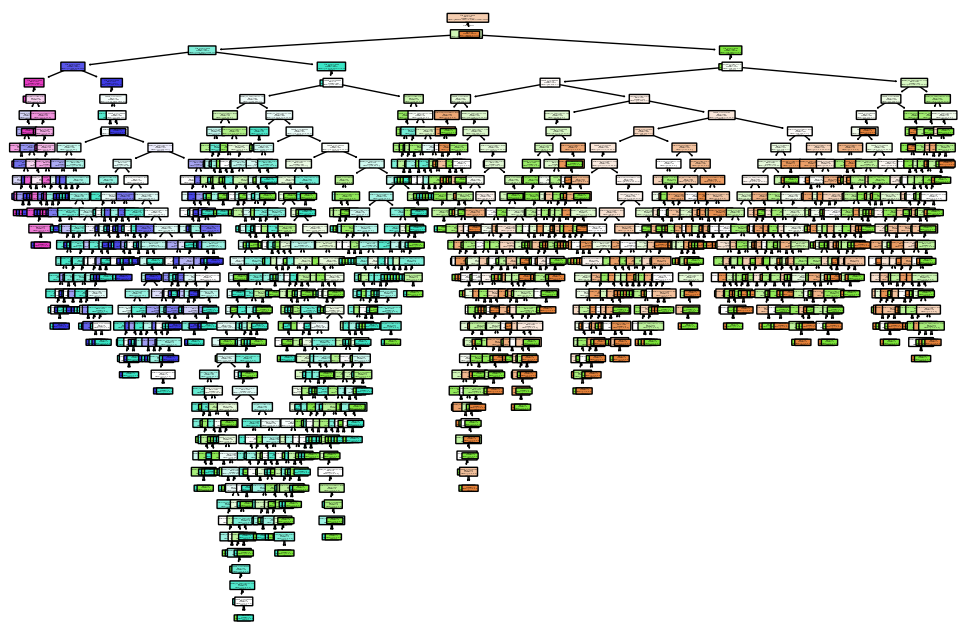

In [52]:
# Decision Tree Visualization



plt.figure(figsize=(12, 8))
plot_tree(
    stp,   
    feature_names=df.drop("grade", axis=1).columns,
    class_names=sorted(df["grade"].astype(str).unique()),
    filled=True,
    rounded=True
)
plt.show()
